In [2]:
# pip install opendatasets --upgrade

In [3]:
# 1. Install legacy-cgi directly into the active kernel environment
import sys

from sklearn.linear_model import LogisticRegression
!{sys.executable} -m pip install legacy-cgi

# 2. Force Python to recognize legacy-cgi as 'cgi' dynamically
try:
    import legacy_cgi
    sys.modules['cgi'] = legacy_cgi
except ImportError:
    pass


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3.13 install --upgrade pip


In [48]:
import opendatasets as od
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [54]:
dataset_url = "https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset/data"
od.download(dataset_url)
# kaggle key: fa6c2af8681796a4a3dc095875508bdb


Skipping, found downloaded files in "./loan-prediction-problem-dataset" (use force=True to force download)


In [53]:
import pandas as pd 
import numpy as np
import matplotlib as mp
import seaborn as sns
import sklearn
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [9]:
# to read the dataframes
df_train = pd.read_csv("/Users/mitushijain/Desktop/Pycharm/Loan Prediction Problem /train_dataset.csv")
df_test = pd.read_csv("/Users/mitushijain/Desktop/Pycharm/Loan Prediction Problem /test_dataset.csv")

In [10]:
# EDA
# Check how many rows and columns
# check the first 5 rows

print(df_test.shape)
print(df_train.shape)

print(df_test.head)
print(df_train.head)


(367, 12)
(614, 13)
<bound method NDFrame.head of       Loan_ID Gender Married Dependents     Education Self_Employed  \
0    LP001015   Male     Yes          0      Graduate            No   
1    LP001022   Male     Yes          1      Graduate            No   
2    LP001031   Male     Yes          2      Graduate            No   
3    LP001035   Male     Yes          2      Graduate            No   
4    LP001051   Male      No          0  Not Graduate            No   
..        ...    ...     ...        ...           ...           ...   
362  LP002971   Male     Yes         3+  Not Graduate           Yes   
363  LP002975   Male     Yes          0      Graduate            No   
364  LP002980   Male      No          0      Graduate            No   
365  LP002986   Male     Yes          0      Graduate            No   
366  LP002989   Male      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5720    

In [11]:
# check for na values
print(df_test.isna().any(axis=None))
print(df_train.isna().any(axis=None))
# there are missing values

True
True


In [12]:
# count how many missing values there are:
print(df_train.isna().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [13]:
# count how many missing values there are:
print(df_test.isna().sum())

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64


In [19]:
# Going to be trying three ways to see which ones works best for the model

# First way: Frequency (For all the numeric values)

print(df_train.dtypes)

df_test['Credit_History'] = df_test['Credit_History'].fillna(df_test['Credit_History'].mean())


df_train['Credit_History'] = df_train['Credit_History'].fillna(df_train['Credit_History'].mean())
df_train['LoanAmount'] = df_train['LoanAmount'].fillna(df_train['LoanAmount'].mean())
df_train['Loan_Amount_Term'] = df_train['Loan_Amount_Term'].fillna(df_train['Loan_Amount_Term'].mean())



Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [23]:
# Second way: Frequency (for categorical)

dependent_freq1 = df_train['Dependents'].value_counts()
self_employed_freq = df_train['Self_Employed'].value_counts()

df_train.replace("Nan",dependent_freq1 , inplace = True)
df_train.replace("Nan",self_employed_freq , inplace = True)

dependent_freq2 = df_test['Dependents'].value_counts()
df_test.replace("Nan",dependent_freq2 , inplace = True)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.000000,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.000000,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.000000,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,0.825444,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.000000,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.000000,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.000000,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,0.825444,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.000000,Rural


In [25]:
numeric_df_train = df_train.select_dtypes(include=['float64', 'int64'])
numeric_df_train.corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565620,-0.045242,-0.014477
CoapplicantIncome,-0.116605,1.000000,0.187828,-0.059675,-0.001665
LoanAmount,0.565620,0.187828,1.000000,0.038801,-0.007738
Loan_Amount_Term,-0.045242,-0.059675,0.038801,1.000000,0.001395
Credit_History,-0.014477,-0.001665,-0.007738,0.001395,1.000000


<Axes: xlabel='ApplicantIncome', ylabel='LoanAmount'>

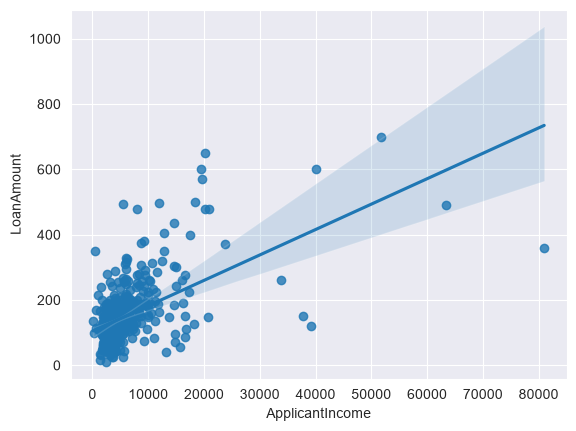

In [26]:
sns.regplot(x = "ApplicantIncome",y = "LoanAmount", data=df_train)

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

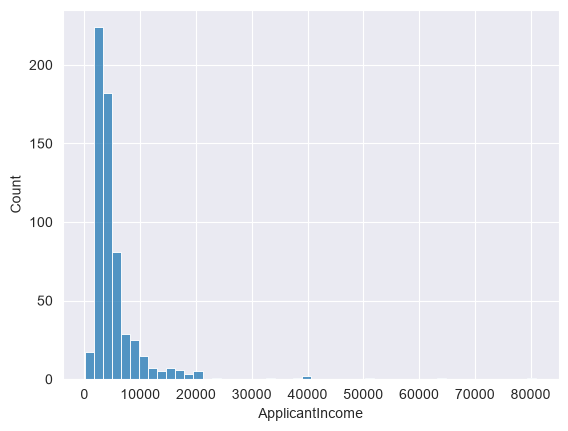

In [28]:
sns.histplot(data = df_train, x="ApplicantIncome")

<Axes: xlabel='Credit_History', ylabel='Count'>

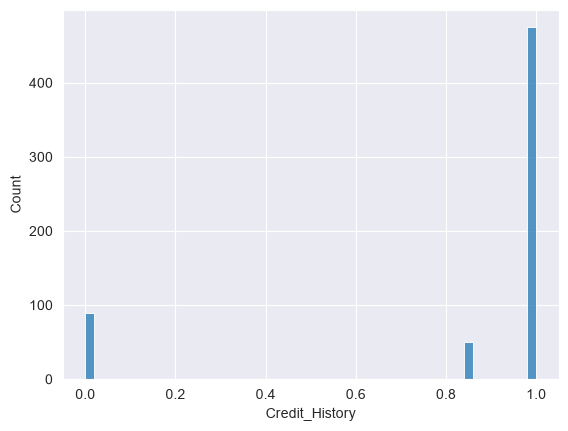

In [29]:
sns.histplot(data = df_train, x="Credit_History")

<Axes: xlabel='Education', ylabel='Count'>

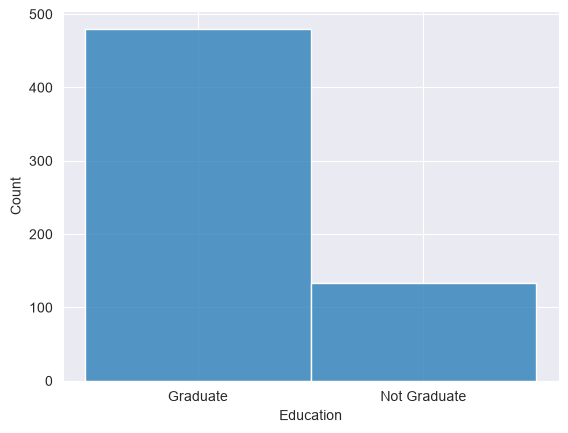

In [30]:
sns.histplot(data = df_train, x="Education")

<Axes: xlabel='Education', ylabel='ApplicantIncome'>

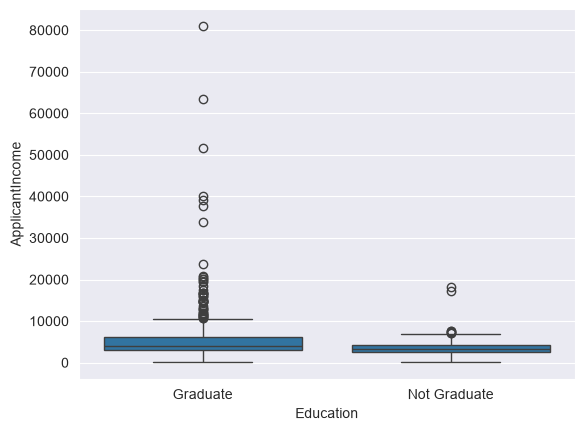

In [32]:
sns.boxplot(data=df_train, x="Education", y="ApplicantIncome")

<Axes: xlabel='Education', ylabel='LoanAmount'>

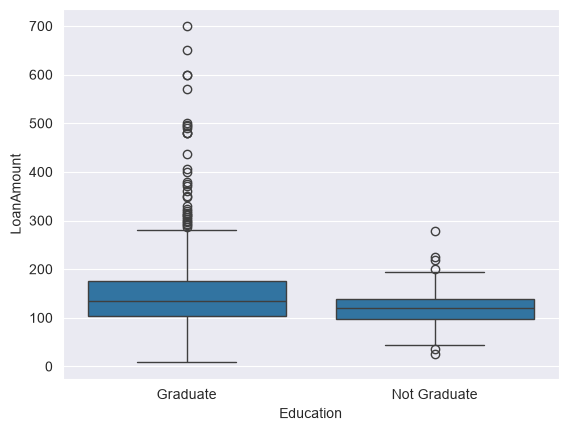

In [39]:
sns.boxplot(data=df_train, x="Education", y="LoanAmount")

<Axes: xlabel='Dependents', ylabel='ApplicantIncome'>

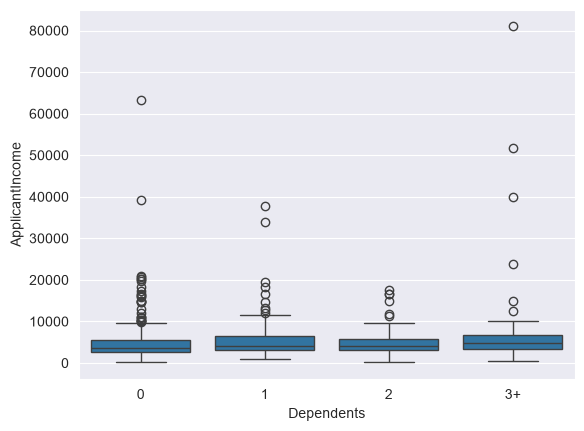

In [33]:
sns.boxplot(data=df_train, x="Dependents", y="ApplicantIncome")

<Axes: xlabel='Dependents', ylabel='LoanAmount'>

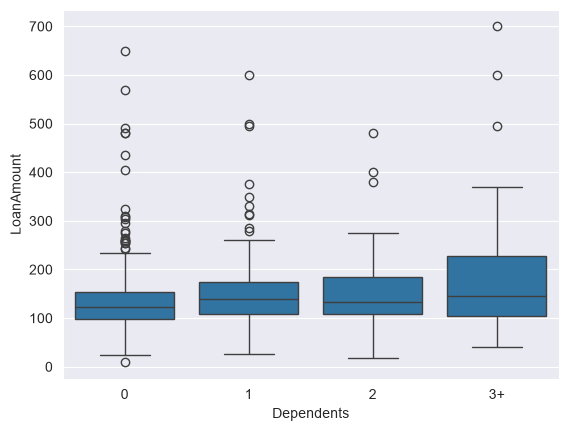

In [38]:
sns.boxplot(data=df_train, x="Dependents", y="LoanAmount")

<Axes: xlabel='Married', ylabel='ApplicantIncome'>

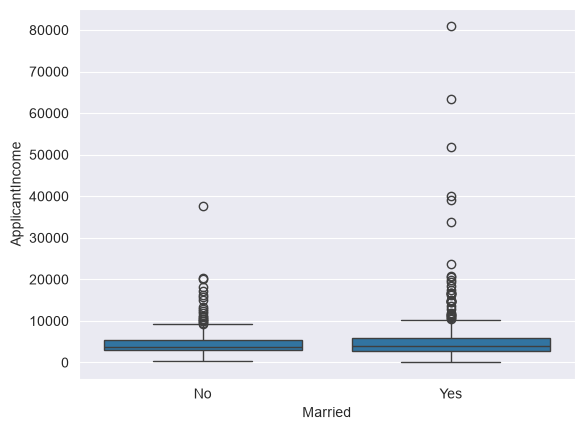

In [34]:
sns.boxplot(data=df_train, x="Married", y="ApplicantIncome")

<Axes: xlabel='Married', ylabel='LoanAmount'>

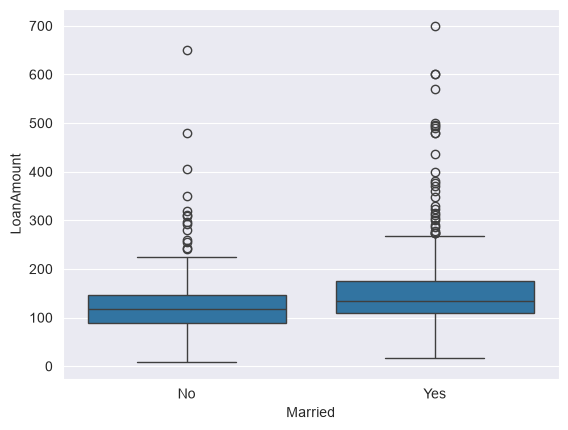

In [35]:
sns.boxplot(data=df_train, x="Married", y="LoanAmount")

<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

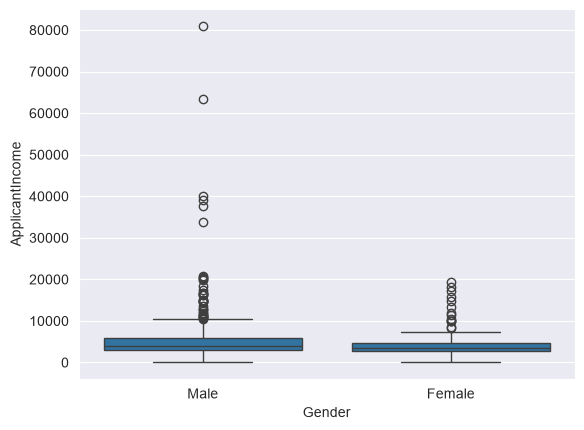

In [36]:
sns.boxplot(data=df_train, x="Gender", y="ApplicantIncome")

<Axes: xlabel='Gender', ylabel='LoanAmount'>

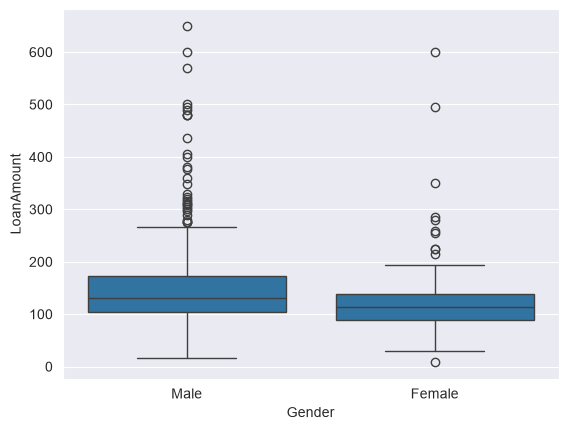

In [37]:
sns.boxplot(data=df_train, x="Gender", y="LoanAmount")

In [60]:
x_data = df_train[["ApplicantIncome", "LoanAmount"]]
y_data = df_train["Loan_Status"]
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state = 0)

In [63]:
# Logistic Regression model
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print(y_pred)
print(accuracy)

['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y']
0.7317073170731707


In [58]:
X,Y= make_moons(n_samples= 300, noise = 0.25, random_state = 3)
x_train, x_test, y_train, y_test = train_test_split(X,Y, stratify = Y, random_state = 42)

forest = RandomForestClassifier(n_estimators = 7, random_state = 2)
forest = forest.fit(x_train, y_train)

In [59]:
print("Accuracy of training set:", forest.score(x_train, y_train))
print("Accuracy of test set:", forest.score(x_test, y_test))

Accuracy of training set: 0.9822222222222222
Accuracy of test set: 0.84
